In [ ]:
#GENERAL
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

#PATH PROCESS
import os
from pathlib import Path
import glob
from scipy.io import loadmat
import json

# image processing
import cv2
from scipy.ndimage import gaussian_filter

# Neural Network
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision

# Paths for Hology dataset
base_dir = "data/"
train_images_dir = os.path.join(base_dir, "train", "images")
train_labels_dir = os.path.join(base_dir, "train", "labels")
test_images_dir = os.path.join(base_dir, "test", "images")

# Exploring Dataset

In [2]:
path_img_ex = os.path.join(train_images_dir, '1.jpg')
image_ex = cv2.cvtColor(cv2.imread(path_img_ex),cv2.COLOR_BGR2RGB)
figure = plt.figure(figsize=(5,5))
plt.imshow(image_ex)
plt.show()

: 

In [3]:
# Read corresponding JSON label
json_ex_path = os.path.join(train_labels_dir, '1.json')
with open(json_ex_path, 'r') as f:
    gt_ex = json.load(f)
print('type: ', type(gt_ex))
print(list(gt_ex.keys()))

type:  <class 'dict'>
['img_id', 'human_num', 'points']


In [4]:
print(gt_ex.keys())

dict_keys(['img_id', 'human_num', 'points'])


In [5]:
gt_points_ex = np.array([[p['x'], p['y']] for p in gt_ex['points']], dtype=np.float32)
print('Shape of coordinates: ', gt_points_ex.shape)


Shape of coordinates:  (539, 2)


The keyword 'image_info' gives the coordinates of location of each person in the image.

The shape[0] indicates the amount of people in the image.

Text(0.5, 1.0, 'Image and Coordinate')

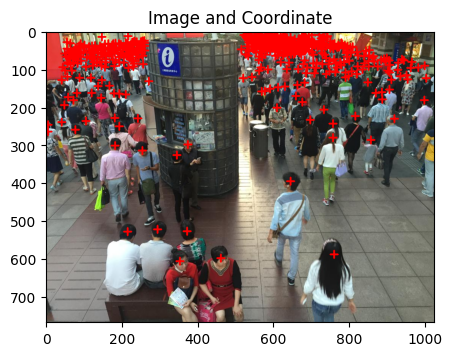

In [6]:
figure = plt.figure(figsize=(5,5))

for x_cor, y_cor in gt_points_ex:
    cv2.drawMarker(image_ex, (int(x_cor), int(y_cor)),(255, 0, 0),thickness=3)

plt.imshow(image_ex)
plt.title("Image and Coordinate")

Extract the coordinate as density map. With the function *create_density_map*, the coordinate of people can be visulized, the sum of the density map is the amount of people in the image, the size of the density map is the same as the image.

The density map will be used as 'label' for neural network.

In [7]:
def gen_density_map_gaussian(image, coords, sigma=5):
    h, w = image.shape[:2]
    img_zeros = np.zeros((h, w), dtype=np.float32)
    if coords is None or len(coords) == 0:
        return gaussian_filter(img_zeros, sigma=sigma, truncate=5*5)

    for x_cor, y_cor in coords:
        if x_cor is None or y_cor is None:
            continue
        if np.isnan(x_cor) or np.isnan(y_cor):
            continue
        xi = int(round(float(x_cor)))
        yi = int(round(float(y_cor)))
        if xi < 0 or yi < 0:
            continue
        if xi >= w:
            xi = w - 1
        if yi >= h:
            yi = h - 1
        img_zeros[yi, xi] = 1

    density_map = gaussian_filter(img_zeros, sigma=sigma, truncate=5*5)
    return density_map

max1 :  tensor(1.)
max2 :  0.05647691
min1 :  tensor(0.)
min2 :  0.0


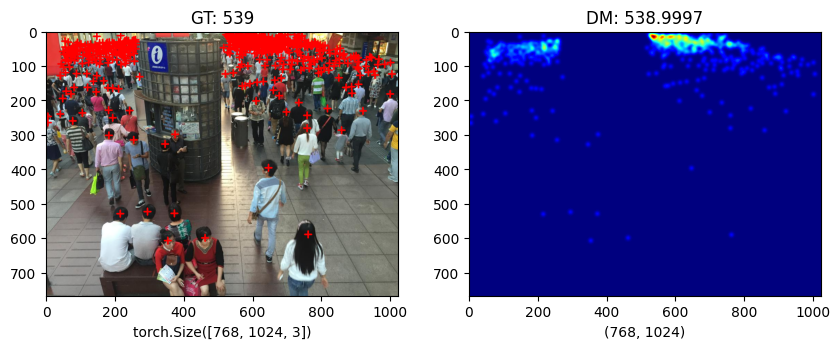

In [8]:
density_map_ex = gen_density_map_gaussian(image_ex, gt_points_ex, 5)

figure = plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
image_ex = torch.tensor(image_ex/255, dtype=torch.float)
plt.xlabel(image_ex.shape)
plt.title('GT: '+str(gt_points_ex.shape[0]))
plt.imshow(image_ex)

plt.subplot(1,2,2)
plt.xlabel(density_map_ex.shape)
plt.title('DM: '+str(np.sum(density_map_ex)))
plt.imshow(density_map_ex, cmap="jet")

print('max1 : ', image_ex.max())
print('max2 : ', density_map_ex.max())
print('min1 : ', image_ex.min())
print('min2 : ', density_map_ex.min())

# Load Data

Create a data loader extract the key 'image_info' in MAT to obtain the coordinates of people location. Then use the *gen_density_map_gaussian* to create the density map of each image. In addition, take the dimension of the coordinate matrix as number of people, which can be used for model loss function. Downsample is applied in order to fit the shape of density map at output of training model.

In [9]:
class TrainValDataset(Dataset):
    def __init__(self, split_csv_path, images_dir, labels_dir, gt_downsample=4, shuffle=False, target_size=(768, 1024)):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.gt_downsample = gt_downsample
        self.shuffle = shuffle
        self.target_h, self.target_w = target_size  # multiples of gt_downsample

        df = pd.read_csv(split_csv_path)
        self.img_names = df['img_id'].tolist()
        if self.shuffle:
            random.shuffle(self.img_names)

        self.n_people = {}
        self.DMs = {}
        for image_filename in self.img_names:
            img_path = os.path.join(self.images_dir, image_filename)
            json_path = os.path.join(self.labels_dir, image_filename.replace('.jpg', '.json'))
            with open(json_path, 'r') as f:
                label = json.load(f)
            img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
            h, w = img.shape[:2]
            # scale points to target size
            pts = np.array([[p['x'], p['y']] for p in label.get('points', [])], dtype=np.float32)
            if pts.size > 0:
                sx = self.target_w / float(w)
                sy = self.target_h / float(h)
                pts[:, 0] = np.clip(np.rint(pts[:, 0] * sx), 0, self.target_w - 1)
                pts[:, 1] = np.clip(np.rint(pts[:, 1] * sy), 0, self.target_h - 1)
            # resize image to target size
            img_resized = cv2.resize(img, (self.target_w, self.target_h))
            self.DMs[img_path] = gen_density_map_gaussian(img_resized, pts, 5)
            self.n_people[img_path] = pts.shape[0]

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, index):
        img_filename = self.img_names[index]
        img_path = os.path.join(self.images_dir, img_filename)
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        # resize to fixed size
        img = cv2.resize(img, (self.target_w, self.target_h))
        gt_density_map = self.DMs[img_path]
        gt_n_people = self.n_people[img_path]

        if len(img.shape) == 2:
            img = img[:, :, np.newaxis]
            img = np.concatenate((img, img, img), 2)

        ds_rows = int(self.target_h // self.gt_downsample)
        ds_cols = int(self.target_w // self.gt_downsample)
        img = cv2.resize(img, (ds_cols*self.gt_downsample, ds_rows*self.gt_downsample))
        gt_density_map = cv2.resize(gt_density_map, (ds_cols, ds_rows))
        gt_density_map = gt_density_map[np.newaxis, :, :] * self.gt_downsample * self.gt_downsample

        img = img.transpose((2,0,1))
        img_tensor = torch.tensor(img/255, dtype=torch.float)
        dm_tensor = torch.tensor(gt_density_map, dtype=torch.float)

        return img_tensor, dm_tensor, gt_n_people


In [ ]:
# Create train/valid split CSVs and sample_submission if missing

def create_splits_and_submission(train_images_dir, train_labels_dir, test_images_dir, base_dir, train_frac=0.8, seed=42):
    os.makedirs(base_dir, exist_ok=True)

    # Collect labeled training images
    all_imgs = [f for f in os.listdir(train_images_dir) if f.lower().endswith('.jpg')]
    labeled_imgs = [f for f in all_imgs if os.path.isfile(os.path.join(train_labels_dir, os.path.splitext(f)[0] + '.json'))]

    def sort_key(name):
        stem = os.path.splitext(name)[0]
        try:
            return (0, int(stem))
        except ValueError:
            return (1, stem)

    labeled_imgs.sort(key=sort_key)

    rng = random.Random(seed)
    rng.shuffle(labeled_imgs)

    split_idx = int(len(labeled_imgs) * train_frac)
    train_ids = labeled_imgs[:split_idx]
    valid_ids = labeled_imgs[split_idx:]

    train_csv = os.path.join(base_dir, 'train_split.csv')
    valid_csv = os.path.join(base_dir, 'valid_split.csv')
    pd.DataFrame({'img_id': train_ids}).to_csv(train_csv, index=False)
    pd.DataFrame({'img_id': valid_ids}).to_csv(valid_csv, index=False)

    # Create sample_submission for test images
    test_imgs = [f for f in os.listdir(test_images_dir) if f.lower().endswith('.jpg')]
    test_imgs.sort(key=sort_key)
    sample_sub_csv = os.path.join(base_dir, 'sample_submission.csv')
    pd.DataFrame({'image_id': test_imgs}).to_csv(sample_sub_csv, index=False)

    print(f'Wrote {len(train_ids)} train and {len(valid_ids)} valid to:')
    print(train_csv)
    print(valid_csv)
    print('Wrote sample_submission to:')
    print(sample_sub_csv)

# Run once to generate CSVs
create_splits_and_submission(train_images_dir, train_labels_dir, test_images_dir, base_dir)


In [ ]:
# Use train split for a quick dataset check
train_split_csv = os.path.join(base_dir, 'train_split.csv')
dataset = TrainValDataset(train_split_csv, train_images_dir, train_labels_dir, gt_downsample=8, shuffle=True)

Print some samples of dataset as a sanity check

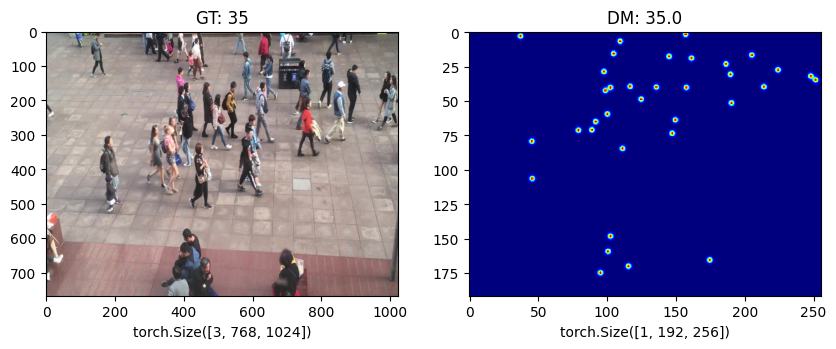

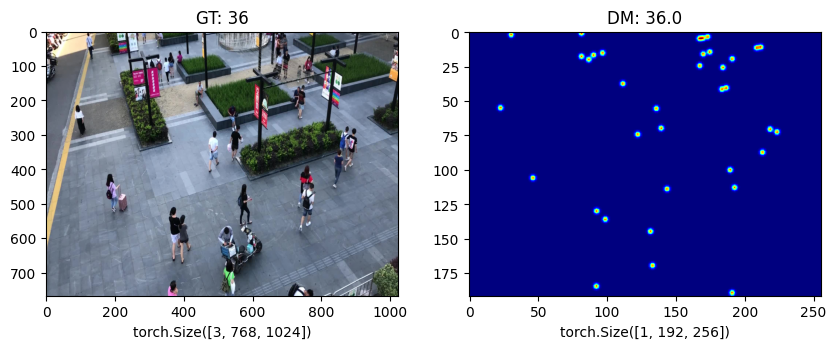

In [11]:
for i, (img, gt_dmap, n_people) in enumerate(dataset):
  plt.figure(figsize=(10, 5))
  plt.subplot(1,2,1)
  plt.xlabel(img.shape)
  plt.title('GT: ' + str(n_people))
  plt.imshow(img.permute(1, 2, 0))

  plt.subplot(1,2,2)
  plt.xlabel(gt_dmap.shape)
  plt.title('DM: ' + str(np.sum(gt_dmap.numpy())))
  plt.imshow(gt_dmap.permute(1, 2, 0), cmap="jet")
  plt.show()

  if i > 0:
    #print('type of img: ', type(img))
    #print('type of dmap: ', type(gt_dmap))
    #print('shape of img: ', img.shape)
    break


# Create Model for Neural Network

In [ ]:
class BasicConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride,
                              padding=padding, dilation=dilation, bias=True)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        return x


class CSRNet(nn.Module):
    """
    CSRNet: VGG-16 frontend up to conv4_3 with three poolings (stride 8),
    followed by a dilated backend, then 1x1 conv to predict density.
    """
    def __init__(self, load_vgg_weights=True):
        super().__init__()
        # Frontend (VGG-16 up to conv4_3, with 3 poolings => stride 8)
        self.frontend = nn.Sequential(
            BasicConv2d(3, 64, 3, padding=1),
            BasicConv2d(64, 64, 3, padding=1),
            nn.MaxPool2d(2),  # /2

            BasicConv2d(64, 128, 3, padding=1),
            BasicConv2d(128, 128, 3, padding=1),
            nn.MaxPool2d(2),  # /4

            BasicConv2d(128, 256, 3, padding=1),
            BasicConv2d(256, 256, 3, padding=1),
            BasicConv2d(256, 256, 3, padding=1),
            nn.MaxPool2d(2),  # /8

            BasicConv2d(256, 512, 3, padding=1),
            BasicConv2d(512, 512, 3, padding=1),
            BasicConv2d(512, 512, 3, padding=1),
            # no pool here (keep /8)
        )

        # Backend with dilated convolutions
        self.backend = nn.Sequential(
            BasicConv2d(512, 512, 3, padding=2, dilation=2),
            BasicConv2d(512, 512, 3, padding=2, dilation=2),
            BasicConv2d(512, 512, 3, padding=2, dilation=2),
            BasicConv2d(512, 256, 3, padding=2, dilation=2),
            BasicConv2d(256, 128, 3, padding=2, dilation=2),
            BasicConv2d(128, 64, 3, padding=2, dilation=2),
        )

        self.output_layer = nn.Conv2d(64, 1, kernel_size=1)

        if load_vgg_weights:
            self._initialize_from_vgg()
        else:
            self._initialize_weights()

    def forward(self, x):
        x = self.frontend(x)
        x = self.backend(x)
        x = self.output_layer(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def _initialize_from_vgg(self):
        vgg = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_FEATURES)
        vgg_features = vgg.features
        # copy first 10 conv layers (up to conv4_3)
        conv_layers = [m for m in vgg_features if isinstance(m, nn.Conv2d)]
        target_convs = [m for m in self.frontend.modules() if isinstance(m, nn.Conv2d)]
        for src, tgt in zip(conv_layers[:len(target_convs)], target_convs):
            if src.weight.shape == tgt.weight.shape:
                tgt.weight.data = src.weight.data.clone()
                if tgt.bias is not None and src.bias is not None:
                    tgt.bias.data = src.bias.data.clone()
        # backend and output keep Kaiming init

# Alias to keep existing training code working
class MC_CNN(CSRNet):
    def __init__(self):
        super().__init__(load_vgg_weights=True)


In [ ]:
img = torch.rand((1,3,768,1024), dtype=torch.float)
model_tmp = MC_CNN()
out_dmap = model_tmp(img)
print(out_dmap.shape)
print('Expected H/8xW/8:', out_dmap.shape[-2:] == (768//8, 1024//8))

torch.Size([1, 1, 192, 256])


# Prepare the data for traning, validation, and testing

In [ ]:
batch_size = 8
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# Datasets from provided splits
train_split_csv = os.path.join(base_dir, 'train_split.csv')
valid_split_csv = os.path.join(base_dir, 'valid_split.csv')

train_dataset = TrainValDataset(train_split_csv, train_images_dir, train_labels_dir, gt_downsample=8, shuffle=True)
val_dataset = TrainValDataset(valid_split_csv, train_images_dir, train_labels_dir, gt_downsample=8, shuffle=False)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Test set has images only
class TestImageDataset(Dataset):
    def __init__(self, images_dir, gt_downsample=8, target_size=(768, 1024)):
        self.images_dir = images_dir
        self.gt_downsample = gt_downsample
        self.target_h, self.target_w = target_size
        self.img_names = sorted([f for f in os.listdir(images_dir) if f.endswith('.jpg')], key=lambda x: int(x.split('.')[0]))

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, index):
        img_filename = self.img_names[index]
        img_path = os.path.join(self.images_dir, img_filename)
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        if len(img.shape) == 2:
            img = img[:, :, np.newaxis]
            img = np.concatenate((img, img, img), 2)
        # resize to fixed size matching training
        img = cv2.resize(img, (self.target_w, self.target_h))
        ds_rows = int(self.target_h // self.gt_downsample)
        ds_cols = int(self.target_w // self.gt_downsample)
        img = cv2.resize(img, (ds_cols*self.gt_downsample, ds_rows*self.gt_downsample))
        img = img.transpose((2,0,1))
        img_tensor = torch.tensor(img/255, dtype=torch.float)
        return img_tensor, img_filename


test_dataset = TestImageDataset(test_images_dir, gt_downsample=8, target_size=(768, 1024))
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Number of batches in train_loader:", len(train_loader))
print("Number of batches in val_loader:", len(val_loader))
print("Number of batches in test_loader:", len(test_loader))

Number of batches in train_loader: 190
Number of batches in val_loader: 48
Number of batches in test_loader: 63


In [15]:
def plot_corresponding_pairs(batch1, batch2, plot_map='jet'):
    num_images = batch1.shape[0] # can change to 4 if for entire data set

    fig, axes = plt.subplots(int(np.ceil(num_images/2)), 4)

    for i in range(num_images):
        axes[int(i/4)*2, i%4].imshow(batch1[i].permute(1, 2, 0))
        axes[int(i/4)*2, i%4].axis('off')

        axes[int(i/4)*2+1, i%4].imshow(batch2[i].squeeze().detach().numpy(), cmap=plot_map)
        axes[int(i/4)*2+1, i%4].axis('off')
        axes[int(i/4)*2+1, i%4].set_title('DM: ' + str(np.sum(batch2[i].detach().numpy())))

    plt.tight_layout()
    plt.show()

Print some samples of dataset as a sanity check

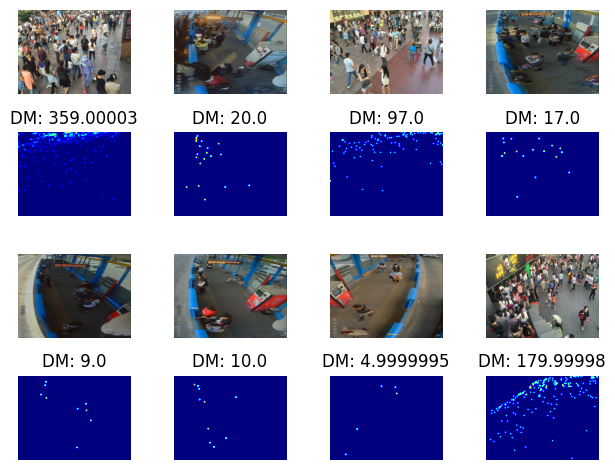

  359    20    97    17     9    10     5   180


In [16]:
dataiter = iter(train_loader)
ex_images, ex_dmaps, ex_n_people = next(dataiter)

# Show images and density map
plot_corresponding_pairs(ex_images, ex_dmaps)

# Print Ground truth number of people
print(' '.join('%5s' % (ex_n_people[j].item() if hasattr(ex_n_people[j], 'item') else ex_n_people[j]) for j in range(min(batch_size, len(ex_n_people)))))

# Training Phase

Define a cost function that considering 
* Difference between density map and predicted image
* Difference between sum of predicted image (refering number of people) and the ground truth number of people

In [17]:
class CombinedLoss(nn.Module):
    def __init__(self, weight_dmap=0.8, weight_sum_gt=0.2):
        super().__init__()
        self.weight_dmap = weight_dmap
        self.weight_sum_gt = weight_sum_gt
        self.img_loss = nn.MSELoss()
        self.gt_loss_mse = nn.MSELoss()
        self.gt_loss_mae = nn.L1Loss()

    def forward(self, logits, batch_dmap, batch_gts):
        batch_gts = batch_gts.float()
        img_loss = self.img_loss(logits, batch_dmap)
        gt_loss_mae = self.gt_loss_mae(torch.squeeze(logits.sum(dim=(2,3))), batch_gts)
        gt_loss_mse = self.gt_loss_mse(torch.squeeze(logits.sum(dim=(2,3))), batch_gts)
        
        #print('logits : ', torch.squeeze(logits.sum(dim=(2,3))))
        #print('gts    : ', batch_gts)
        #print('MAE:  ', gt_loss_mae)
        
        combined_loss = self.weight_dmap * img_loss + self.weight_sum_gt * gt_loss_mae
        return combined_loss, gt_loss_mae

In [ ]:
num_epochs = 15
#train_losses = np.zeros(num_epochs)
#val_losses = np.zeros(num_epochs)
train_losses = []
val_losses = []
train_mae_losses = []
val_mae_losses = []


model = MC_CNN().to(device)
criterion = CombinedLoss(0.8, 0.2)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
best_val_loss = np.inf
best_nr_epoch = 0

for epoch in range(num_epochs):
    print("Epoch {}:".format(epoch))

    # training phase
    tr_loss_acc = 0.0
    tr_loss_mae_acc = 0.0

    for batch_img, batch_dmap, batch_gts in train_loader:
        # Put data on device
        batch_img, batch_dmap, batch_gts = batch_img.to(device), batch_dmap.to(device), batch_gts.to(device)
        # Predict and get loss
        logits = model(batch_img)
        loss, mae_loss = criterion(logits, batch_dmap, batch_gts)
        # Update model
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Keep running statistics
        tr_loss_acc += loss.item()
        tr_loss_mae_acc += mae_loss.item()
        #print('acc mae = ', tr_loss_mae_acc)
        

    tr_loss = tr_loss_acc / len(train_loader.dataset) # change to this when entire dataset
    tr_mae = tr_loss_mae_acc / len(train_loader.dataset)
    print('>> TRAIN: Epoch {} | tr_loss:  {:.6f}'.format(epoch, tr_loss))
    print('>> TRAIN: Epoch {} | mae:      {:.6f}'.format(epoch, tr_mae))
    
    # Get validation results
    with torch.inference_mode():
        val_loss_acc = 0.0
        val_loss_mae_acc = 0.0
        
        for batch_img_val, batch_dmap_val, batch_gts_val in val_loader:
            # Put data on device
            batch_img_val, batch_dmap_val, batch_gts_val = batch_img_val.to(device), batch_dmap_val.to(device), batch_gts_val.to(device)

            # Predict and get loss
            logits = model(batch_img_val)
            loss, mae_loss = criterion(logits, batch_dmap_val, batch_gts_val)

            # Keep running statistics
            val_loss_acc += loss.item()
            val_loss_mae_acc += mae_loss.item()

    val_loss = val_loss_acc / len(val_loader.dataset)
    val_mae = val_loss_mae_acc / len(val_loader.dataset)
    print('>> VAL:   Epoch {} | val_loss: {:.6f}'.format(epoch, val_loss))
    print('>> VAL:   Epoch {} | mae:      {:.6f}'.format(epoch, val_mae))

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_nr_epoch = epoch
        torch.save(model.state_dict(), './csrnet.pth')


    train_losses.append(tr_loss)
    train_mae_losses.append(tr_mae)
    val_losses.append(val_loss)
    val_mae_losses.append(val_mae)
    
print('best training MAE: ', train_mae_losses[best_nr_epoch])  
print('best val MAE:      ', val_mae_losses[best_nr_epoch])  

Epoch 0:
>> TRAIN: Epoch 0 | tr_loss:  10.901490
>> TRAIN: Epoch 0 | mae:      54.506987
>> VAL:   Epoch 0 | val_loss: 6.404467
>> VAL:   Epoch 0 | mae:      32.022188
Epoch 1:
>> TRAIN: Epoch 1 | tr_loss:  3.197214
>> TRAIN: Epoch 1 | mae:      15.985933
>> VAL:   Epoch 1 | val_loss: 2.012042
>> VAL:   Epoch 1 | mae:      10.060080
Epoch 2:
>> TRAIN: Epoch 2 | tr_loss:  2.899110
>> TRAIN: Epoch 2 | mae:      14.495416
>> VAL:   Epoch 2 | val_loss: 2.794692
>> VAL:   Epoch 2 | mae:      13.973327
Epoch 3:
>> TRAIN: Epoch 3 | tr_loss:  3.344517
>> TRAIN: Epoch 3 | mae:      16.722452
>> VAL:   Epoch 3 | val_loss: 4.019076
>> VAL:   Epoch 3 | mae:      20.095250
Epoch 4:
>> TRAIN: Epoch 4 | tr_loss:  2.807388
>> TRAIN: Epoch 4 | mae:      14.036809
>> VAL:   Epoch 4 | val_loss: 2.069215
>> VAL:   Epoch 4 | mae:      10.345949
Epoch 5:
>> TRAIN: Epoch 5 | tr_loss:  2.488930
>> TRAIN: Epoch 5 | mae:      12.444521
>> VAL:   Epoch 5 | val_loss: 2.515736
>> VAL:   Epoch 5 | mae:      12.5785

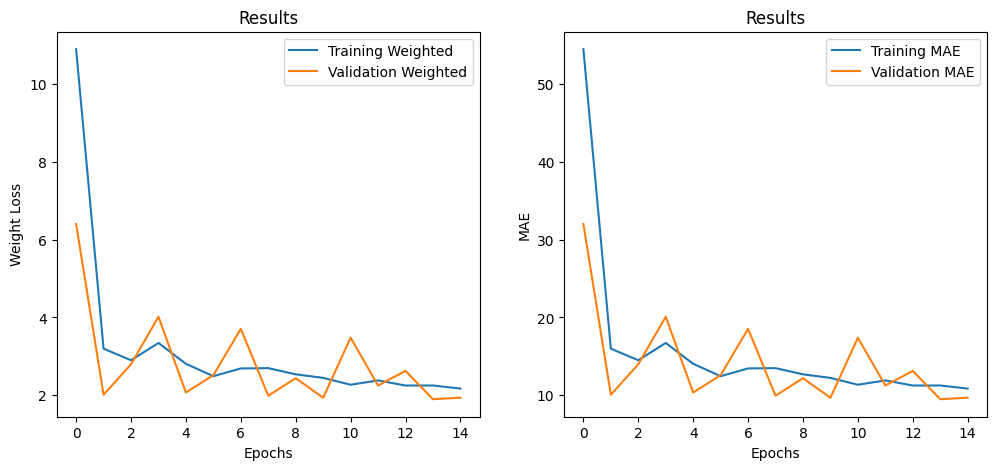

In [19]:
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Weighted')
plt.plot(val_losses, label='Validation Weighted')
plt.title('Results')
plt.ylabel('Weight Loss')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_mae_losses, label='Training MAE')
plt.plot(val_mae_losses, label='Validation MAE')
plt.title('Results')
plt.ylabel('MAE')
plt.xlabel('Epochs')
plt.legend()

plt.show()

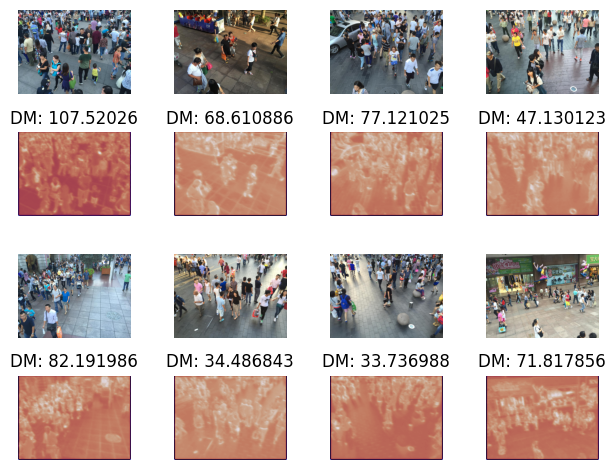

  147    29    58    50   106    45    78    53


In [ ]:
best_model = MC_CNN().to(device)
best_model.load_state_dict(torch.load('./csrnet.pth'))
# Get some random validation images
dataiter = iter(val_loader)
ex_images, _, ex_gts  = next(dataiter)


# Show images and density map

pred_dms = best_model(ex_images.to(device))
plot_corresponding_pairs(ex_images.cpu(), pred_dms.cpu(), 'twilight')

# Print labels
print(' '.join('%5s' % ex_gts[j].item() for j in range(batch_size)))

# Test Phase

In [ ]:
# Generate predictions and submission CSV
best_model = MC_CNN().to(device)
best_model.load_state_dict(torch.load('./csrnet.pth', map_location=device))
best_model.eval()

submission_rows = []
with torch.inference_mode():
    for batch in test_loader:
        batch_imgs, batch_filenames = batch
        batch_imgs = batch_imgs.to(device)
        logits = best_model(batch_imgs)
        counts = torch.squeeze(logits.sum(dim=(2,3))).detach().cpu().numpy()
        for fname, count in zip(batch_filenames, counts):
            submission_rows.append({
                'image_id': fname,
                'predicted_count': max(0, float(count))
            })

submission_df = pd.DataFrame(submission_rows)
# Ensure the same ordering as sample_submission
sample_sub = pd.read_csv(os.path.join(base_dir, 'sample_submission.csv'))
submission_df = sample_sub[['image_id']].merge(submission_df, on='image_id', how='left')
submission_df['predicted_count'] = submission_df['predicted_count'].fillna(0)

out_path = os.path.join(base_dir, 'submission.csv')
submission_df.to_csv(out_path, index=False)
print('Saved submission to:', out_path)
print(submission_df.head())

Saved submission to: /home/salsazufar/hology/submission.csv
  image_id  predicted_count
0    1.jpg        15.591911
1    2.jpg        89.757004
2    3.jpg       160.166565
3    4.jpg       489.287933
4    5.jpg       113.614159


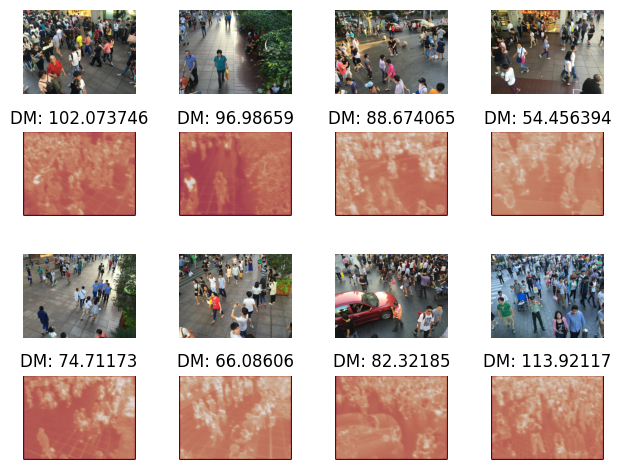

  117    29    89    45    73    47    90   170


In [ ]:
# Get some random test images
dataiter = iter(test_loader)
ex_images, ex_names = next(dataiter)

# Show images and density map
pred_dms = best_model(ex_images.to(device))
plot_corresponding_pairs(ex_images.cpu(), pred_dms.cpu(), 'twilight')